# Purpose of this EDA Notebook

The goal of this exploratory data analysis is to:

1. Understand the structure, quality, and completeness of the fintech complaint dataset.
2. Identify missing values and assess which columns are useful for NLP analysis.
3. Analyze complaint patterns across products, issues, companies, and time.
4. Examine complaint text characteristics (length, distribution) to guide preprocessing.
5. Extract initial insights to support risk scoring and prioritization of high-impact complaints.

# Step 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2. Load Dataset (CSV – Optimized & Fast)

In [2]:
file_path = r"C:\Users\hp\Desktop\Fintech_Complaint_Analysis\data\raw\complaints.csv"

use_cols = [
    'Consumer complaint narrative',
    'Product',
    'Issue',
    'Company',
    'Date received'
]

df = pd.read_csv(
    file_path,
    usecols=use_cols,                                                              # usecols → load only required columns
    nrows=30000
)

df.head()


,Date received,Product,Issue,Consumer complaint narrative,Company
0,2020-07-06,"Credit reporting, credit repair services, or o...",Incorrect information on your report,NaN,Experian Information Solutions Inc.
1,2025-11-25,Credit reporting or other personal consumer re...,Incorrect information on your report,NaN,"EQUIFAX, INC."
2,2025-10-14,Credit reporting or other personal consumer re...,Incorrect information on your report,My credit report contains incorrect and mislea...,"EQUIFAX, INC."
3,2025-10-26,Credit reporting or other personal consumer re...,Incorrect information on your report,Be sure that disputed accounts are taken down ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC."
4,2025-10-10,Credit reporting or other personal consumer re...,Incorrect information on your report,NaN,"EQUIFAX, INC."


# Step 3. General Dataset Statistics

In [3]:
df.shape

(30000, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Date received                 30000 non-null  object
 1   Product                       30000 non-null  object
 2   Issue                         30000 non-null  object
 3   Consumer complaint narrative  3324 non-null   object
 4   Company                       30000 non-null  object
dtypes: object(5)
memory usage: 1.1+ MB


##### Understand data size, Check data types, Spot missing values early

# Step 4. Missing Value Analysis

In [5]:
df.isnull().sum()

Date received                       0
Product                             0
Issue                               0
Consumer complaint narrative    26676
Company                             0
dtype: int64

In [6]:
(df.isnull().mean() * 100).round(2)

Date received                    0.00
Product                          0.00
Issue                            0.00
Consumer complaint narrative    88.92
Company                          0.00
dtype: float64

In [7]:
df.describe(include='all')

,Date received,Product,Issue,Consumer complaint narrative,Company
count,30000,30000,30000,3324,30000
unique,1499,17,107,2786,628
top,2025-11-12,Credit reporting or other personal consumer re...,Incorrect information on your report,You have reported inaccurate and unauthorized ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC."
freq,417,26118,16039,60,9284


In [8]:
df.info()
df.isnull().sum()
(df.isnull().mean() * 100).round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Date received                 30000 non-null  object
 1   Product                       30000 non-null  object
 2   Issue                         30000 non-null  object
 3   Consumer complaint narrative  3324 non-null   object
 4   Company                       30000 non-null  object
dtypes: object(5)
memory usage: 1.1+ MB


Date received                    0.00
Product                          0.00
Issue                            0.00
Consumer complaint narrative    88.92
Company                          0.00
dtype: float64

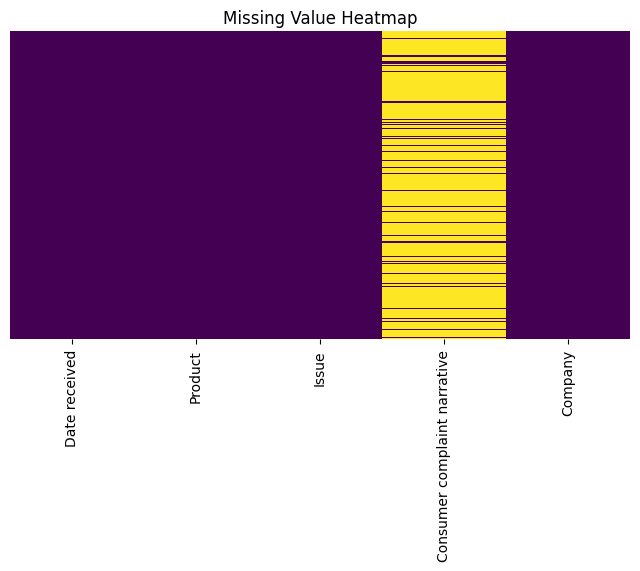

In [9]:
# Missing value visualization

import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap of missing values
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()


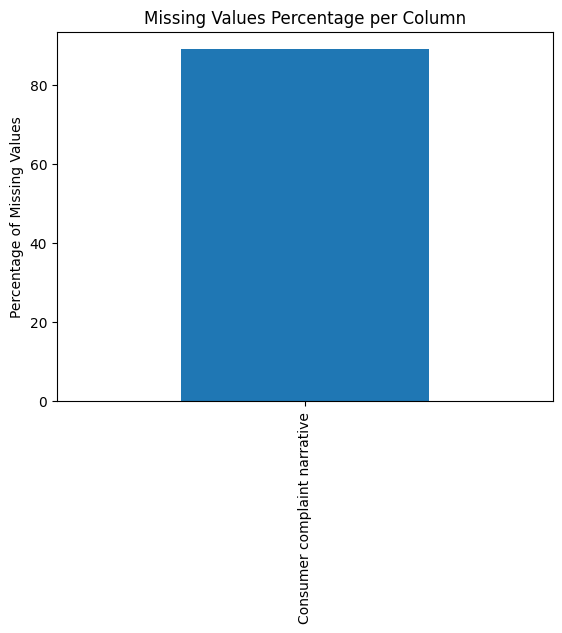

In [10]:
# Bar chart to see % of missing values per column

missing_percent = (df.isnull().mean() * 100).round(2)
missing_percent = missing_percent[missing_percent > 0]

missing_percent.plot(kind='bar')
plt.ylabel("Percentage of Missing Values")
plt.title("Missing Values Percentage per Column")
plt.show()


# Step 5. Product & Issue Analysis

In [11]:
df['Product'].value_counts().head(10)

Product
Credit reporting or other personal consumer reports                             26118
Debt collection                                                                  1524
Credit reporting, credit repair services, or other personal consumer reports      635
Credit card                                                                       419
Checking or savings account                                                       408
Money transfer, virtual currency, or money service                                224
Mortgage                                                                          211
Vehicle loan or lease                                                             118
Student loan                                                                      102
Credit card or prepaid card                                                        91
Name: count, dtype: int64

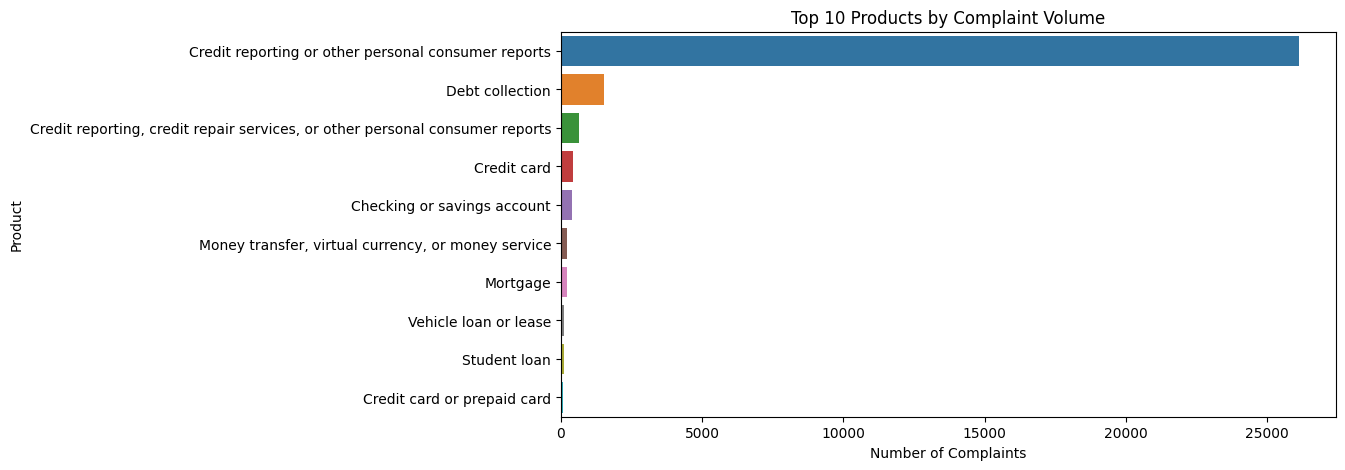

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(
    y=df['Product'],
    order=df['Product'].value_counts().head(10).index
)
plt.title("Top 10 Products by Complaint Volume")
plt.xlabel("Number of Complaints")
plt.ylabel("Product")
plt.show()


In [13]:
# Issue Distribution

df['Issue'].value_counts().head(10)


Issue
Incorrect information on your report                                                16039
Improper use of your report                                                          5699
Problem with a company's investigation into an existing problem                      4767
Attempts to collect debt not owed                                                     580
Took or threatened to take negative or legal action                                   331
Written notification about debt                                                       308
Managing an account                                                                   243
False statements or representation                                                    206
Problem with a credit reporting company's investigation into an existing problem      167
Problem with a purchase shown on your statement                                       132
Name: count, dtype: int64

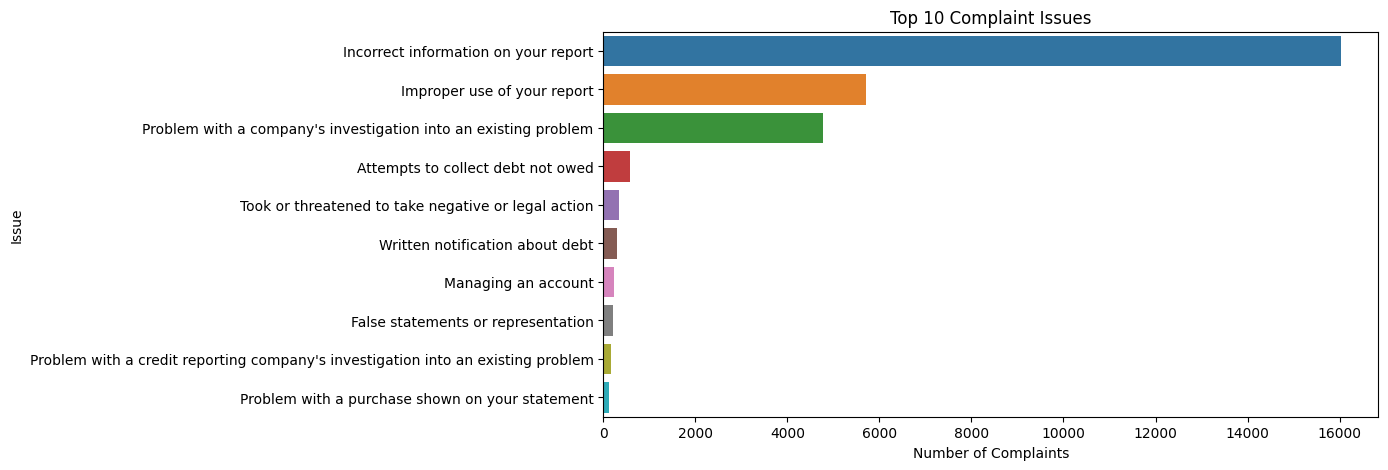

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(
    y=df['Issue'],
    order=df['Issue'].value_counts().head(10).index
)
plt.title("Top 10 Complaint Issues")
plt.xlabel("Number of Complaints")
plt.ylabel("Issue")
plt.show()


# Step 6. Complaint Text Length Analysis

In [15]:
df = df[df['Consumer complaint narrative'].notnull()]
df['text_length'] = df['Consumer complaint narrative'].apply(len)
df['text_length'].describe()


count     3324.000000
mean      1075.572804
std       1149.050877
min         15.000000
25%        402.750000
50%        757.500000
75%       1332.250000
max      18523.000000
Name: text_length, dtype: float64

C:\Users\hp\Desktop\Fintech_Complaint_Analysis\venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


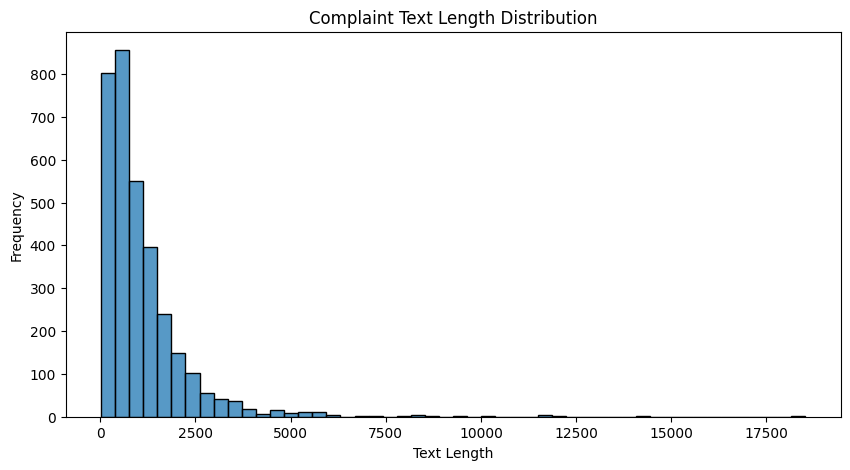

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(df['text_length'], bins=50)
plt.title("Complaint Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()


# Step 7. Company Analysis

In [17]:
df['Company'].value_counts().head(10)

Company
TRANSUNION INTERMEDIATE HOLDINGS, INC.    885
EQUIFAX, INC.                             682
Experian Information Solutions Inc.       571
WELLS FARGO & COMPANY                      54
CAPITAL ONE FINANCIAL CORPORATION          54
CITIBANK, N.A.                             52
BANK OF AMERICA, NATIONAL ASSOCIATION      43
JPMORGAN CHASE & CO.                       39
SYNCHRONY FINANCIAL                        36
Block, Inc.                                31
Name: count, dtype: int64

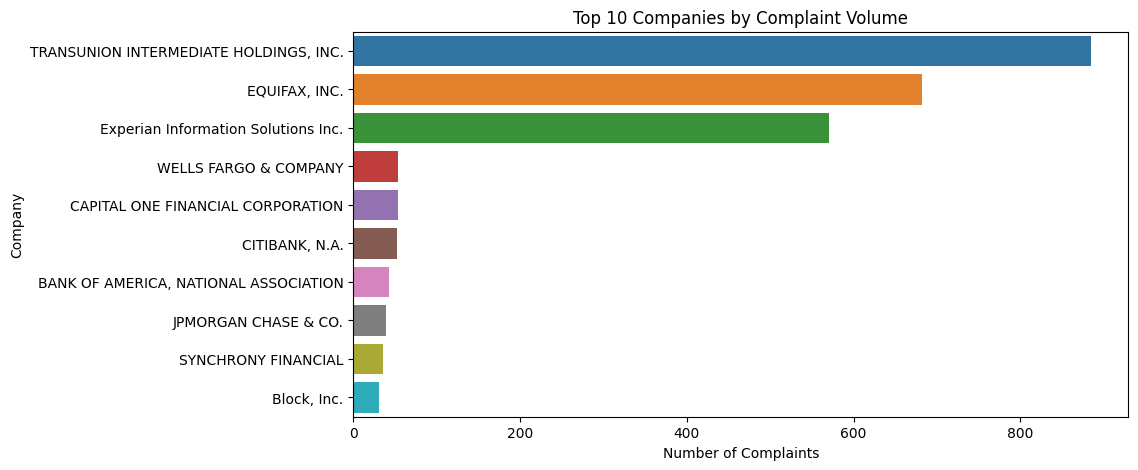

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(
    y=df['Company'],
    order=df['Company'].value_counts().head(10).index
)
plt.title("Top 10 Companies by Complaint Volume")
plt.xlabel("Number of Complaints")
plt.ylabel("Company")
plt.show()


# Step 8. Time-Based Analysis

In [19]:
df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')
df['year'] = df['Date received'].dt.year


In [20]:
df['year'].value_counts().sort_index()

year
2015       9
2016      11
2017      21
2018      41
2019     159
2020     161
2021      46
2022      52
2023     165
2024     219
2025    2440
Name: count, dtype: int64

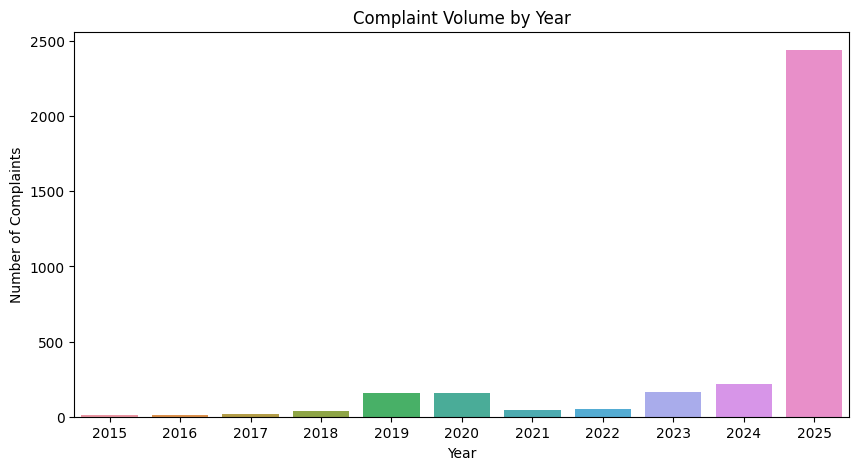

In [21]:
plt.figure(figsize=(10,5))
sns.countplot(x='year', data=df)
plt.title("Complaint Volume by Year")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.show()

# Step 9.  Initial Risk Insights

Initial Risk Insights:
- High complaint concentration in specific products and issues
- Longer complaint narratives may indicate more complex or severe issues
- Certain companies consistently receive higher complaint volumes
- Temporal trends suggest changing customer risk patterns

# Step 10. Summary of Observations

EDA Summary:
- Dataset contains meaningful complaint narratives suitable for NLP analysis
- Product and issue categories show imbalance, indicating potential risk concentration
- Text length analysis confirms the need for cleaning and normalization
- EDA insights will guide preprocessing and risk scoring


During EDA, I analyzed complaint patterns, text characteristics, company distributions, and temporal trends to extract early risk signals. These insights directly informed the preprocessing and risk modeling steps.